<a href="https://colab.research.google.com/github/khupkhaidopmul-stack/lis4693/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import altair as alt
from vega_datasets import data as vega_data

In [2]:
import requests
import io

url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-3/Seattle-Library_2015-2021.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text


In [3]:
seattle_df = pd.read_csv(io.StringIO(text))
seattle_df.head()

,Title,Creator,MaterialType,Checkouts,CheckoutYear,CheckoutMonth,Publisher,PublicationYear,Subjects,UsageClass,CheckoutType
0,Frog and toad all year / by Arnold Lobel.,"Lobel, Arnold",BOOK,34,2016,10,"Harper & Row,",c1976.,"Friendship Fiction, Frogs Juvenile fiction, To...",Physical,Horizon
1,"My brilliant friend : childhood, adolescence /...","Ferrante, Elena",BOOK,110,2016,10,"Europa Editions,",2012,"Friendship Fiction, Naples Italy Fiction",Physical,Horizon
2,Star trek [videorecording] / Paramount ; Spygl...,NaN,VIDEODISC,36,2016,10,"Paramount Home Entertainment,",c2009.,"Kirk James T 2233 2371 Drama, Spock Mr Drama, ...",Physical,Horizon
3,The Man in the High Castle,Philip K. Dick,EBOOK,63,2016,10,Houghton Mifflin Harcourt Trade and Reference,2012,"Fiction, Science Fiction",Digital,OverDrive
4,"The Fifth Season: Broken Earth Series, Book 1",N. K. Jemisin,EBOOK,44,2016,10,"Hachette Digital, Inc.",2015,"Fantasy, Fiction, Thriller",Digital,OverDrive


<Axes: xlabel='MaterialType'>

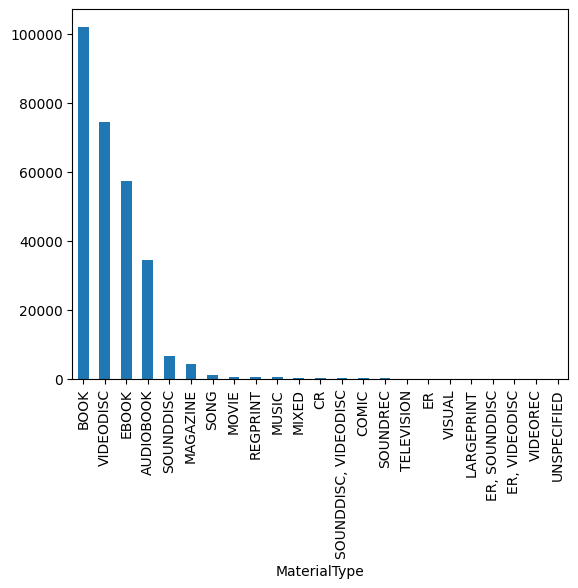

In [4]:
seattle_df['MaterialType'].value_counts().plot(kind='bar')

In [5]:
source = pd.DataFrame({
    'a': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'],
    'b': [28, 55, 43, 91, 81, 53, 19, 87, 52]
})

alt.Chart(source).mark_bar().encode(
    x='a',
    y='b'
)

alt.Chart(...)

In [6]:
seattle_df['MaterialType'].value_counts()

,count
MaterialType,
BOOK,102076
VIDEODISC,74473
EBOOK,57299
AUDIOBOOK,34542
SOUNDDISC,6593
MAGAZINE,4197
SONG,975
MOVIE,596
REGPRINT,447


In [7]:
type(seattle_df['MaterialType'].value_counts())

pandas.core.series.Series

In [8]:
seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')

,MaterialType,counts
0,BOOK,102076
1,VIDEODISC,74473
2,EBOOK,57299
3,AUDIOBOOK,34542
4,SOUNDDISC,6593
5,MAGAZINE,4197
6,SONG,975
7,MOVIE,596
8,REGPRINT,447
9,MUSIC,382


In [9]:
source = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')
alt.Chart(source).mark_bar().encode(
    x='MaterialType',
    y='counts'
)


alt.Chart(...)

In [10]:
source = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')
alt.Chart(source).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts'
)


alt.Chart(...)

In [11]:
cars = vega_data.cars()

alt.Chart(cars).mark_point().encode(
    x='Horsepower',
    y='Miles_per_Gallon',
    color='Origin',
    shape='Origin'
)

alt.Chart(...)

In [12]:
seattle_df

,Title,Creator,MaterialType,Checkouts,CheckoutYear,CheckoutMonth,Publisher,PublicationYear,Subjects,UsageClass,CheckoutType
0,Frog and toad all year / by Arnold Lobel.,"Lobel, Arnold",BOOK,34,2016,10,"Harper & Row,",c1976.,"Friendship Fiction, Frogs Juvenile fiction, To...",Physical,Horizon
1,"My brilliant friend : childhood, adolescence /...","Ferrante, Elena",BOOK,110,2016,10,"Europa Editions,",2012,"Friendship Fiction, Naples Italy Fiction",Physical,Horizon
2,Star trek [videorecording] / Paramount ; Spygl...,NaN,VIDEODISC,36,2016,10,"Paramount Home Entertainment,",c2009.,"Kirk James T 2233 2371 Drama, Spock Mr Drama, ...",Physical,Horizon
3,The Man in the High Castle,Philip K. Dick,EBOOK,63,2016,10,Houghton Mifflin Harcourt Trade and Reference,2012,"Fiction, Science Fiction",Digital,OverDrive
4,"The Fifth Season: Broken Earth Series, Book 1",N. K. Jemisin,EBOOK,44,2016,10,"Hachette Digital, Inc.",2015,"Fantasy, Fiction, Thriller",Digital,OverDrive
...,...,...,...,...,...,...,...,...,...,...,...
282282,The Fire Next Time,James Baldwin,EBOOK,23,2021,5,"Random House, Inc.",2013,"Sociology, African American Nonfiction, Nonfic...",Digital,OverDrive
282283,"Girl, woman, other / Bernardine Evaristo.","Evaristo, Bernardine, 1959-",BOOK,22,2021,5,"Black Cat, an imprint of Grove Atlantic,",[2019],"Women Black Great Britain Fiction, Great Brita...",Physical,Horizon
282284,Your Money or Your Life: 9 Steps to Transformi...,Vicki Robin,AUDIOBOOK,30,2021,5,Books on Tape,2018,"Business, Finance, Self-Improvement, Nonfiction",Digital,OverDrive
282285,Harry Potter and the Order of the Phoenix: Har...,J. K. Rowling,EBOOK,32,2021,5,Pottermore,2012,"Juvenile Fiction, Juvenile Literature",Digital,OverDrive


In [17]:
alt.Chart(seattle_df).mark_bar().encode(
     x=alt.X('MaterialType', sort='-y'),
     y='count()',
     color='CheckoutYear:N'
 )


MaxRowsError: The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.Chart(...)

In [18]:
seattle_material_grouped = seattle_df.groupby(['MaterialType', 'CheckoutYear']).size().reset_index(name='counts')
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color='CheckoutYear:N'
)


alt.Chart(...)

In [19]:
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color='CheckoutYear:N',
    tooltip=['MaterialType', 'counts', 'CheckoutYear']
).interactive()


alt.Chart(...)

In [20]:
selection = alt.selection_point(fields=['CheckoutYear'], bind='legend')
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color=alt.Color('CheckoutYear:N', sort=alt.EncodingSortField('CheckoutYear', order='descending')),
    tooltip=['MaterialType', 'counts', 'CheckoutYear'],
    opacity=alt.condition(selection, alt.value(1), alt.value(0.2)),
    order='CheckoutYear'
).add_params(
    selection
)

alt.Chart(...)

What went well:

Creating the visualizations with Altair went well. I was able to load the Seattle Library dataset and successfully create two different charts using different marks. Adding interactivity such as tooltips and zooming was straightforward using Altair’s built-in features. Combining both charts side-by-side using horizontal concatenation also worked smoothly and made it easy to compare the visualizations.

What did not go well / Challenges:

One challenge I encountered was figuring out which columns from the Seattle Library dataset worked best for visualization. Some columns required adjusting the data types to display correctly in the charts. It also took some time to understand how Altair encoding works and how to properly combine the charts using horizontal concatenation. However, after reviewing the documentation and examples, I was able to resolve these issues.